<a href="https://colab.research.google.com/github/Aziz4785/ML/blob/master/laplacian_eigenmaps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx -q


In [ ]:
# Install packages if needed
!pip install -q scikit-learn plotly


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.datasets import make_s_curve
import numpy as np
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csgraph
import sklearn.manifold
import plotly.graph_objects as go
from plotly.offline import iplot

## **Laplacian eigenmap 1D**

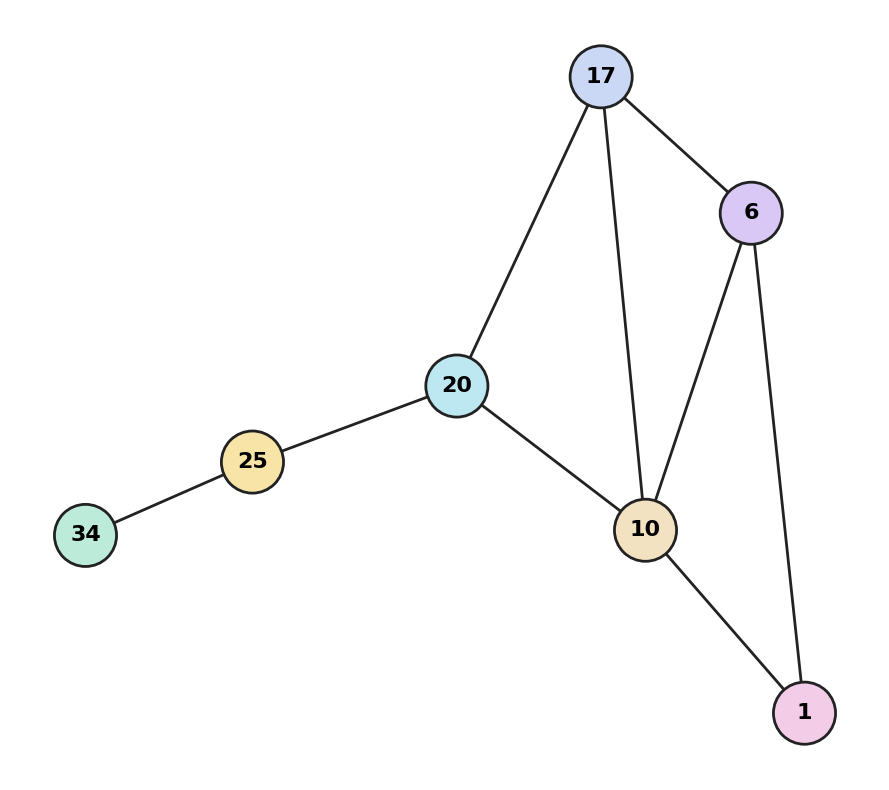

In [17]:

points = [34, 6, 17, 10, 1, 20, 25]

nodes = list(range(len(points)))

G = nx.Graph()
G.add_nodes_from(nodes)

edges = [
    (0, 6),  # first 34 -- 25
    (6, 5),  # 25 -- 20
    (5, 2),  # 20 -- 17
    (5, 3),
    (3, 2),
    (2, 1),  # 17 -- 6
    (1, 3),  # 6 -- 10
    (3, 4),  # 10 -- 1
    (4, 1),  # 1 -- 6
]

G.add_edges_from(edges)

labels = {node: points[node] for node in nodes}

colors = [
    "#bdebd9",
    "#d9c8f5",  # 6
    "#cbd8f5",  # 17
    "#f3e2c2",  # 10
    "#f3cce8",  # 1
    "#bde8f1",  # 20
    "#f9e4a8",  # 25
]


pos = nx.spring_layout(G, seed=10)

plt.figure(figsize=(9, 8))

nx.draw_networkx_edges(
    G,
    pos,
    width=2,
    edge_color="#222222"
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=colors,
    node_size=2000,
    edgecolors="#222222",
    linewidths=2
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=16,
    font_weight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

**Now we compute the Adjancy Matrix of that graph**

In [18]:
# Create the adjacency matrix
adj_matrix = nx.to_numpy_array(G, nodelist=nodes, dtype=int)

print(adj_matrix)
# Display it with point values as row and column labels
adj_df = pd.DataFrame(
    adj_matrix,
    index=points,
    columns=points
)

display(adj_df)

[[0 0 0 0 0 0 1]
 [0 0 1 1 1 0 0]
 [0 1 0 1 0 1 0]
 [0 1 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 1 0 0 1]
 [1 0 0 0 0 1 0]]


,34,6,17,10,1,20,25
34,0,0,0,0,0,0,1
6,0,0,1,1,1,0,0
17,0,1,0,1,0,1,0
10,0,1,1,0,1,1,0
1,0,1,0,1,0,0,0
20,0,0,1,1,0,0,1
25,1,0,0,0,0,1,0


In [19]:

degrees = [G.degree(node) for node in nodes]

# Create the diagonal degree matrix
degree_matrix = np.diag(degrees)

degree_df = pd.DataFrame(
    degree_matrix,
    index=points,
    columns=points
)

display(degree_df)

,34,6,17,10,1,20,25
34,1,0,0,0,0,0,0
6,0,3,0,0,0,0,0
17,0,0,3,0,0,0,0
10,0,0,0,4,0,0,0
1,0,0,0,0,2,0,0
20,0,0,0,0,0,3,0
25,0,0,0,0,0,0,2


In [20]:
# Compute the Laplacian matrix
laplacian_matrix = degree_matrix - adj_matrix

print( laplacian_matrix)

laplacian_df = pd.DataFrame(
    laplacian_matrix,
    index=points,
    columns=points
)

display(laplacian_df)

[[ 1  0  0  0  0  0 -1]
 [ 0  3 -1 -1 -1  0  0]
 [ 0 -1  3 -1  0 -1  0]
 [ 0 -1 -1  4 -1 -1  0]
 [ 0 -1  0 -1  2  0  0]
 [ 0  0 -1 -1  0  3 -1]
 [-1  0  0  0  0 -1  2]]


,34,6,17,10,1,20,25
34,1,0,0,0,0,0,-1
6,0,3,-1,-1,-1,0,0
17,0,-1,3,-1,0,-1,0
10,0,-1,-1,4,-1,-1,0
1,0,-1,0,-1,2,0,0
20,0,0,-1,-1,0,3,-1
25,-1,0,0,0,0,-1,2


In [21]:


# Compute the Laplacian matrix
laplacian_matrix = degree_matrix - adj_matrix

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(laplacian_matrix)

print("Laplacian matrix:")
print(laplacian_matrix)


# Each column eigenvectors[:, i] corresponds to eigenvalues[i]
for i, eigenvalue in enumerate(eigenvalues):
    print(f"\nEigenvalue {i + 1}: {eigenvalue}")
    print(f"Eigenvector {i + 1}: {eigenvectors[:, i]}")
    if i>1:
      break

Laplacian matrix:
[[ 1  0  0  0  0  0 -1]
 [ 0  3 -1 -1 -1  0  0]
 [ 0 -1  3 -1  0 -1  0]
 [ 0 -1 -1  4 -1 -1  0]
 [ 0 -1  0 -1  2  0  0]
 [ 0  0 -1 -1  0  3 -1]
 [-1  0  0  0  0 -1  2]]

Eigenvalue 1: -4.5859160176280113e-17
Eigenvector 1: [-0.37796447 -0.37796447 -0.37796447 -0.37796447 -0.37796447 -0.37796447
 -0.37796447]

Eigenvalue 2: 0.39050380732242296
Eigenvector 2: [ 0.70276264 -0.3096633  -0.21782441 -0.24538339 -0.34485741 -0.01336528
  0.42833115]

Eigenvalue 3: 1.7402149517593217
Eigenvector 3: [-0.43626435 -0.18002669  0.29758847  0.03476762 -0.55915102  0.52015658
  0.3229294 ]


## **Laplacian EigenMAP 3D**

In [22]:
def create_spiral_manifold(
    n_points=3000,
    num_rotations=1.2,
    random_state=0
):
    """

    The original 2D coordinates are:
        u: position along the spiral axis
        v: position around and away from the spiral
    """
    rng = np.random.default_rng(random_state)

    # Random points in the unit square [0, 1] x [0, 1]
    manifold_2d = rng.random((n_points, 2))

    u = manifold_2d[:, 0]
    v = manifold_2d[:, 1]

    # Same transformation used in the notebook
    radius = 0.5 * np.exp(v * num_rotations)
    theta = 2 * np.pi * num_rotations * v

    spiral = np.column_stack([
        6 * u,
        radius * np.cos(theta),
        radius * np.sin(theta)
    ])

    return spiral, v

In [28]:
# Generate the 3D S-curve data
n_points = 3000

s_curve, colors = make_s_curve(
    n_samples=n_points,
    noise=0.0,
    random_state=0
)
# s_curve, colors = create_spiral_manifold(
#     n_points=n_points,
#     num_rotations=1.2,
#     random_state=0
# )


df = pd.DataFrame({
    "X": s_curve[:, 0],
    "Y": s_curve[:, 1],
    "Z": s_curve[:, 2],
    "Position": colors
})

# Create the interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x="X",
    y="Y",
    z="Z",
    color="Position",
    color_continuous_scale="Viridis",
    title="3D S-Curve",
    opacity=0.8
)

fig.update_traces(
    marker={
        "size": 3
    }
)

fig.update_layout(
    width=900,
    height=700,
    scene={
        "xaxis_title": "X",
        "yaxis_title": "Y",
        "zaxis_title": "Z",
        "aspectmode": "data"
    }
)

fig.show()

In [29]:


# Coordinates used to compute Euclidean distances
coordinates = df[["X", "Y", "Z"]].to_numpy()

# Directed 4-nearest-neighbor adjacency matrix:
# A[i, j] = 1 when point j is among point i's 6 closest neighbors.
A_directed = kneighbors_graph(
    coordinates,
    n_neighbors=10,
    mode="connectivity",
    metric="euclidean",
    include_self=False
)

# Convert to an undirected graph using the union rule:
# i and j are connected if either one considers the other a neighbor.
A = A_directed.maximum(A_directed.T).tocsr()

# Remove any accidental diagonal entries
A.setdiag(0)
A.eliminate_zeros()

# Degree matrix: D[i, i] = degree of node i
degrees = np.asarray(A.sum(axis=1)).ravel()
D = csgraph.laplacian(A, normed=False) + A
D = D.tocsr()

# Unnormalized graph Laplacian: L = D - A
L = csgraph.laplacian(A, normed=False).tocsr()

print("Adjacency matrix shape:", A.shape)
print("Laplacian matrix shape:", L.shape)
print("Number of undirected edges:", A.nnz // 2)

Adjacency matrix shape: (3000, 3000)
Laplacian matrix shape: (3000, 3000)
Number of undirected edges: 17200


we compute the eigenvectors with the smallest eigenvalues

In [30]:
import numpy as np
from scipy.sparse.linalg import eigsh

# Compute the four smallest eigenvalues and corresponding eigenvectors
eigenvalues, eigenvectors = eigsh(
    L.astype(float),
    k=14,
    which="SM"  # smallest magnitude eigenvalues
)

# Ensure ascending order
order = np.argsort(eigenvalues)
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Eigenvalues:")
print(eigenvalues)

print("Eigenvectors shape:")
print(eigenvectors.shape)

Eigenvalues:
[2.42222896e-15 3.42461177e-03 1.35729374e-02 3.06576518e-02
 5.41432488e-02 6.67569739e-02 7.09800028e-02 8.42755298e-02
 8.77382769e-02 9.98285051e-02 1.21421110e-01 1.28713070e-01
 1.56361060e-01 1.65966207e-01]
Eigenvectors shape:
(3000, 14)


In [31]:

v2 = eigenvectors[:, 1]
v3 = eigenvectors[:, 2]
#the first eigenvector has an eigenvalue of 0 , we don't want that
print("eigven vector 1 : ")
print(v2)
print("eigven vector 2 : ")
print(v3)


eigven vector 1 : 
[ 0.00332034  0.01642824  0.00762816 ... -0.01357144  0.02096008
  0.01461163]
eigven vector 2 : 
[ 0.02475998  0.00475486  0.02073267 ...  0.01198236 -0.00805941
  0.00919403]


In [32]:
#we stack them as columns :
V = np.column_stack((v2, eigenvectors[:, 2]))
print(V)
print(coordinates)

[[ 0.00332034  0.02475998]
 [ 0.01642824  0.00475486]
 [ 0.00762816  0.02073267]
 ...
 [-0.01357144  0.01198236]
 [ 0.02096008 -0.00805941]
 [ 0.01461163  0.00919403]]
[[ 0.44399868  0.82792499 -0.10397256]
 [ 0.89724097  1.25923661 -1.44154121]
 [ 0.8240493   1.55716853 -0.43348191]
 ...
 [-0.99580717  1.39304575  1.09147723]
 [ 0.18542121  0.96739323 -1.98265914]
 [ 0.9583415   0.67910146 -1.28562488]]


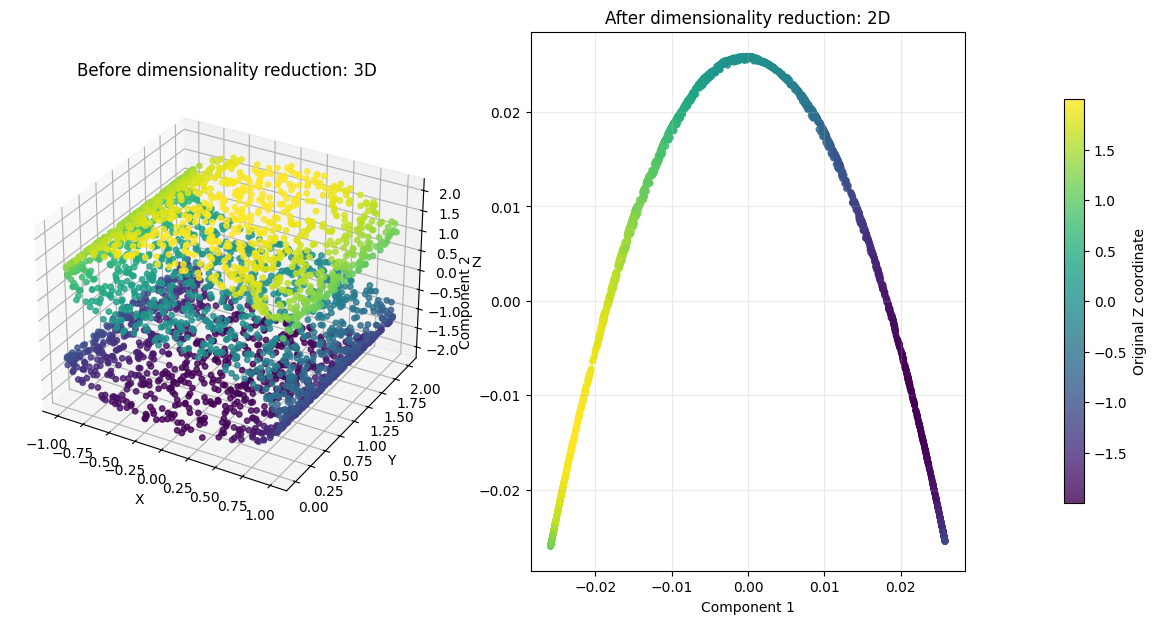

In [33]:


from matplotlib.colors import Normalize

coordinates = np.asarray(coordinates)
V = np.asarray(V)

# Check that rows correspond between the two arrays
assert coordinates.ndim == 2 and coordinates.shape[1] == 3
assert V.ndim == 2 and V.shape[1] == 2
assert coordinates.shape[0] == V.shape[0], (
    "coordinates and V must contain the same number of points"
)

# Color every point according to its original Z coordinate
point_colors = coordinates[:, 2]

# Use exactly the same color scale in both plots
color_norm = Normalize(
    vmin=point_colors.min(),
    vmax=point_colors.max()
)

fig = plt.figure(figsize=(16, 7))

# -------------------------
# Original 3D representation
# -------------------------
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

scatter_3d = ax1.scatter(
    coordinates[:, 0],
    coordinates[:, 1],
    coordinates[:, 2],
    c=point_colors,
    cmap="viridis",
    norm=color_norm,
    s=15,
    alpha=0.8
)

ax1.set_title("Before dimensionality reduction: 3D")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# -------------------------
# Reduced 2D representation
# -------------------------
ax2 = fig.add_subplot(1, 2, 2)

scatter_2d = ax2.scatter(
    V[:, 0],
    V[:, 1],
    c=point_colors,
    cmap="viridis",
    norm=color_norm,
    s=15,
    alpha=0.8
)

ax2.set_title("After dimensionality reduction: 2D")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")
ax2.grid(alpha=0.25)

# Shared color bar
colorbar = fig.colorbar(
    scatter_2d,
    ax=[ax1, ax2],
    shrink=0.75,
    pad=0.08
)

colorbar.set_label("Original Z coordinate")

plt.show()